In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("skillcraft_task4_raw.csv")
df

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,2021-01-02
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,199996,TechCorp,Display,All Ages,30 days,Google Ads,0.06,"$18,365.00",2.84,Chicago,German,858,5988,1,Tech Enthusiasts,2021-12-07
199996,199997,DataTech Solutions,Email,Men 25-34,15 days,Facebook,0.02,"$8,168.00",4.14,Chicago,Spanish,228,3068,7,Foodies,2021-12-08
199997,199998,DataTech Solutions,Social Media,Men 18-24,45 days,Website,0.05,"$13,397.00",3.25,New York,Mandarin,723,9548,3,Tech Enthusiasts,2021-12-09
199998,199999,Innovate Industries,Influencer,All Ages,30 days,YouTube,0.10,"$18,508.00",3.86,Houston,French,528,2763,1,Foodies,2021-12-10


In [4]:
df.isnull().sum()

Campaign_ID         0
Company             0
Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Conversion_Rate     0
Acquisition_Cost    0
ROI                 0
Location            0
Language            0
Clicks              0
Impressions         0
Engagement_Score    0
Customer_Segment    0
Date                0
dtype: int64

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       200000 non-null  int64  
 1   Company           200000 non-null  str    
 2   Campaign_Type     200000 non-null  str    
 3   Target_Audience   200000 non-null  str    
 4   Duration          200000 non-null  str    
 5   Channel_Used      200000 non-null  str    
 6   Conversion_Rate   200000 non-null  float64
 7   Acquisition_Cost  200000 non-null  str    
 8   ROI               200000 non-null  float64
 9   Location          200000 non-null  str    
 10  Language          200000 non-null  str    
 11  Clicks            200000 non-null  int64  
 12  Impressions       200000 non-null  int64  
 13  Engagement_Score  200000 non-null  int64  
 14  Customer_Segment  200000 non-null  str    
 15  Date              200000 non-null  str    
dtypes: float64(2), int64(4), str(10

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,Campaign_ID,Conversion_Rate,ROI,Clicks,Impressions,Engagement_Score
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,100000.500000,0.080070,5.002438,549.772030,5507.301520,5.494710
std,57735.171256,0.040602,1.734488,260.019056,2596.864286,2.872581
min,1.000000,0.010000,2.000000,100.000000,1000.000000,1.000000
25%,50000.750000,0.050000,3.500000,325.000000,3266.000000,3.000000
50%,100000.500000,0.080000,5.010000,550.000000,5517.500000,5.000000
75%,150000.250000,0.120000,6.510000,775.000000,7753.000000,8.000000
max,200000.000000,0.150000,8.000000,1000.000000,10000.000000,10.000000


In [8]:
df['Duration'].unique()

<StringArray>
['30 days', '60 days', '15 days', '45 days']
Length: 4, dtype: str

In [9]:
#duration is str to change to int
df['Duration']=df['Duration'].str.replace('days','').astype(int)

In [10]:
df['Duration'].unique()

array([30, 60, 15, 45])

In [11]:
df['Acquisition_Cost'].head()
#removing , and $
df['Acquisition_Cost']=df['Acquisition_Cost'].str.replace('$','').str.replace(',','').astype(float)

In [12]:
df['Acquisition_Cost'].unique()

array([16174., 11566., 10200., ..., 14111., 13941., 15040.],
      shape=(15001,))

In [13]:
df.dtypes

Campaign_ID           int64
Company                 str
Campaign_Type           str
Target_Audience         str
Duration              int64
Channel_Used            str
Conversion_Rate     float64
Acquisition_Cost    float64
ROI                 float64
Location                str
Language                str
Clicks                int64
Impressions           int64
Engagement_Score      int64
Customer_Segment        str
Date                    str
dtype: object

In [14]:
#changind date from str to date
df['Date']=pd.to_datetime(df['Date'])

In [15]:
cat_cols = ['Company','Campaign_Type','Target_Audience',
            'Channel_Used','Location',
            'Language','Customer_Segment']

for col in cat_cols:
    print(df[col].value_counts())
    print("----------------")

Company
TechCorp               40237
Alpha Innovations      40051
DataTech Solutions     40012
NexGen Systems         39991
Innovate Industries    39709
Name: count, dtype: int64
----------------
Campaign_Type
Influencer      40169
Search          40157
Display         39987
Email           39870
Social Media    39817
Name: count, dtype: int64
----------------
Target_Audience
Men 18-24      40258
Men 25-34      40023
All Ages       40019
Women 25-34    40013
Women 35-44    39687
Name: count, dtype: int64
----------------
Channel_Used
Email         33599
Google Ads    33438
YouTube       33392
Instagram     33392
Website       33360
Facebook      32819
Name: count, dtype: int64
----------------
Location
Miami          40269
New York       40024
Chicago        40010
Los Angeles    39947
Houston        39750
Name: count, dtype: int64
----------------
Language
Mandarin    40255
Spanish     40102
German      39983
English     39896
French      39764
Name: count, dtype: int64
---------------

Campaign_Type
Influencer      5.011068
Search          5.008357
Display         5.006551
Email           4.994295
Social Media    4.991784
Name: ROI, dtype: float64


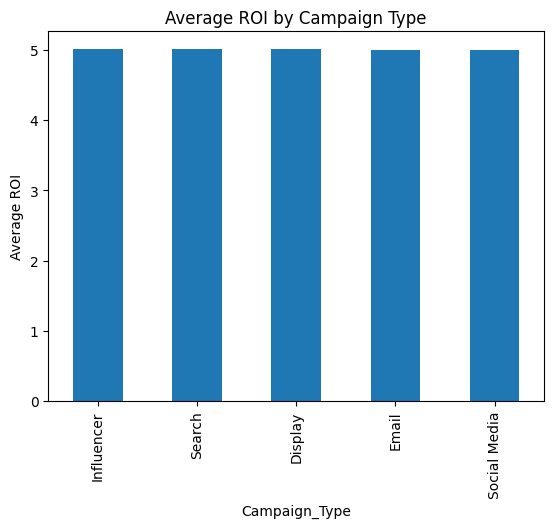

In [ ]:
campaign_roi = (
    df.groupby('Campaign_Type')['ROI']
      .mean()
      .sort_values(ascending=False)
)
print(campaign_roi)
campaign_roi.plot(kind='bar')
plt.ylabel('Average ROI')
plt.title('Average ROI by Campaign Type')
plt.show()

Channel_Used
Facebook      5.018699
Website       5.014167
Google Ads    5.003141
Email         4.996487
YouTube       4.993754
Instagram     4.988706
Name: ROI, dtype: float64


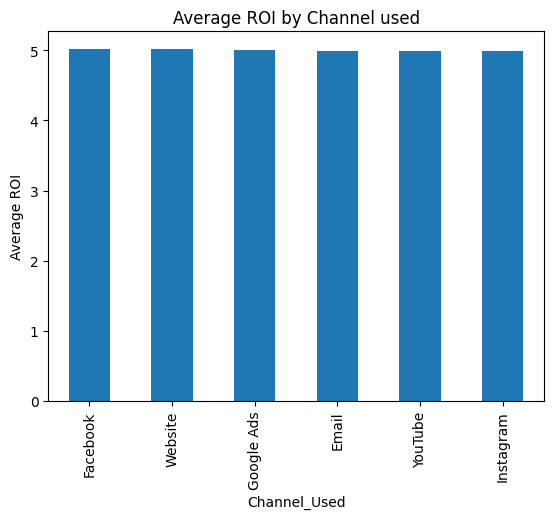

In [30]:
channel_roi = (
    df.groupby('Channel_Used')['ROI']
      .mean()
      .sort_values(ascending=False)
)
print(channel_roi)
channel_roi.plot(kind='bar')
plt.ylabel('Average ROI')
plt.title('Average ROI by Channel used')
plt.show()

Customer_Segment
Foodies                5.004376
Tech Enthusiasts       5.004234
Health & Wellness      5.003202
Fashionistas           5.000962
Outdoor Adventurers    4.999393
Name: ROI, dtype: float64


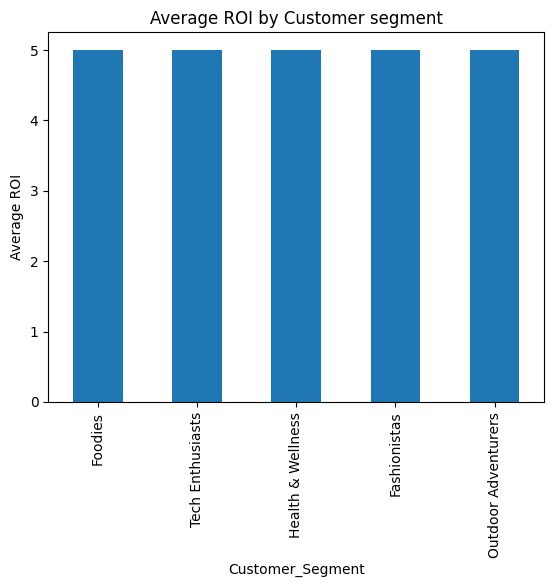

In [29]:
customer_roi = (
    df.groupby('Customer_Segment')['ROI']
      .mean()
      .sort_values(ascending=False)
)
print(customer_roi)
customer_roi.plot(kind='bar')
plt.ylabel('Average ROI')
plt.title('Average ROI by Customer segment')
plt.show()